# Data Analysis

Log

- 19/01/2025: Init

In [5]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sklearn.preprocessing as skp
from rich import print as rprint

## Helpers

In [6]:
def extract_nr_of_sd_attributes(x: str) -> int:
    mi = re.match('.*-sd-(\d{3})-att', x)
    if mi is None or len(mi.groups()) < 1:
        raise Exception(f'Could not extract the number of selectively disclosed attributes from the given input string: {x}')
    return int(mi.group(1))

## Data

In [7]:
!ls -l data/

total 61888
-rw-r--r--  1 gertjandm  staff   3024778 Jan 29 02:15 records-202501290231.json
-rw-r--r--  1 gertjandm  staff   4503929 Feb  6 14:47 records-202502062144.json
-rw-r--r--  1 gertjandm  staff   9033480 Feb  7 00:33 records-202502070033.json
-rw-r--r--@ 1 gertjandm  staff     13995 Feb  7 02:04 records-202502070033.xlsx
-rw-r--r--  1 gertjandm  staff  15082337 Feb  7 01:42 records-202502070205.json
-rw-r--r--  1 gertjandm  staff     12781 Feb  7 13:48 records-202502070205.xlsx


In [9]:
# default
fpath_records = './data/records.json'

#fpath_records = './data/records-202501290231.json'
#fpath_records = './data/records-202502062144.json'
#fpath_records = './data/records-202502070033.json'
fpath_records = './data/records-202502070205.json'

bname_records = os.path.basename(fpath_records).replace('.json','')
fpath_xl_output = os.path.join('data',f'{bname_records}.xlsx')
def get_df() -> pd.DataFrame:
    rprint(f'[bold red] Creating df from {fpath_records}')
    return pd.read_json(fpath_records)

In [10]:
df = get_df()
print('df.shape: ', df.shape)
print('df ∑nRecords: ', df.nRecords.sum())
print('df head')
display(df.head(3))
print('df tail')
display(df.tail(3))

# df.records: each value in this column is a list of records
# a: dataframe with exploded df.records, i.e., each row corresponds to a single record object
a = df.explode('records',)
print('a.shape: ', a.shape)
display(a.head(3))

# b: dataframe created from the records objects
b = a.records.apply(pd.Series)
print('b.shape: ', b.shape)
display(b.head(3))

 Creating df from ./data/records-202502070205.json

df.shape:  (12000, 8)
df ∑nRecords:  84000
df head


,records,nRecords,cryptosuite,implementationClass,credentialSetupKey,nrCredentialSubjectAttributes,nrDisclosedCredentialSubjectAttributes,iteration
0,"[{'name': 'START_SIGN_VC', 'entryType': 'mark'...",8,bbs-bls-signature-2020,Implementation_BbsBlsSignature2020,vc01-sd-002-att,3,2,0
1,"[{'name': 'START_SIGN_VC', 'entryType': 'mark'...",8,bbs-termwise-signature-2023,Implementation_BbsTermwiseSignature2023,vc01-sd-002-att,3,2,0
2,"[{'name': 'START_SIGN_VC', 'entryType': 'mark'...",4,ed25519-signature-2020,Implementation_Ed25519Signature2020,vc01-sd-002-att,3,2,0


df tail


,records,nRecords,cryptosuite,implementationClass,credentialSetupKey,nrCredentialSubjectAttributes,nrDisclosedCredentialSubjectAttributes,iteration
11997,"[{'name': 'START_SIGN_VC', 'entryType': 'mark'...",8,bbs-termwise-signature-2023,Implementation_BbsTermwiseSignature2023,Iso18013DriversLicenseCredential-sd-016-att,21,16,499
11998,"[{'name': 'START_SIGN_VC', 'entryType': 'mark'...",4,ed25519-signature-2020,Implementation_Ed25519Signature2020,Iso18013DriversLicenseCredential-sd-016-att,21,16,499
11999,"[{'name': 'START_SIGN_VC', 'entryType': 'mark'...",8,ecdsa-sd-2023-cryptosuite,Implementation_EcdsaSd2023Cryptosuite,Iso18013DriversLicenseCredential-sd-016-att,21,16,499


a.shape:  (84000, 8)


,records,nRecords,cryptosuite,implementationClass,credentialSetupKey,nrCredentialSubjectAttributes,nrDisclosedCredentialSubjectAttributes,iteration
0,"{'name': 'START_SIGN_VC', 'entryType': 'mark',...",8,bbs-bls-signature-2020,Implementation_BbsBlsSignature2020,vc01-sd-002-att,3,2,0
0,"{'name': 'END_SIGN_VC', 'entryType': 'mark', '...",8,bbs-bls-signature-2020,Implementation_BbsBlsSignature2020,vc01-sd-002-att,3,2,0
0,"{'name': 'START_VERIFY_VC', 'entryType': 'mark...",8,bbs-bls-signature-2020,Implementation_BbsBlsSignature2020,vc01-sd-002-att,3,2,0


b.shape:  (84000, 5)


,name,entryType,startTime,duration,detail
0,START_SIGN_VC,mark,688.945167,0,{'implementation': 'bbs-bls-signature-2020'}
0,END_SIGN_VC,mark,821.288959,0,{'implementation': 'bbs-bls-signature-2020'}
0,START_VERIFY_VC,mark,821.726584,0,{'implementation': 'bbs-bls-signature-2020'}


`c = merge(a,b)`

In [11]:
c = a[['iteration','implementationClass', 'credentialSetupKey']]\
    .drop_duplicates()\
    .merge(b[['name', 'entryType', 'startTime']], left_index=True, right_index=True)
print('c.shape: ', c.shape)
display(c.head(3))

c.shape:  (84000, 6)


,iteration,implementationClass,credentialSetupKey,name,entryType,startTime
0,0,Implementation_BbsBlsSignature2020,vc01-sd-002-att,START_SIGN_VC,mark,688.945167
0,0,Implementation_BbsBlsSignature2020,vc01-sd-002-att,END_SIGN_VC,mark,821.288959
0,0,Implementation_BbsBlsSignature2020,vc01-sd-002-att,START_VERIFY_VC,mark,821.726584


Filter: only keep `mark` entries.

In [12]:
d = c[c.entryType == 'mark']
print('d.shape: ', d.shape)
d.head(3)

d.shape:  (84000, 6)


,iteration,implementationClass,credentialSetupKey,name,entryType,startTime
0,0,Implementation_BbsBlsSignature2020,vc01-sd-002-att,START_SIGN_VC,mark,688.945167
0,0,Implementation_BbsBlsSignature2020,vc01-sd-002-att,END_SIGN_VC,mark,821.288959
0,0,Implementation_BbsBlsSignature2020,vc01-sd-002-att,START_VERIFY_VC,mark,821.726584


Some final preprocessing.

In [13]:
e = d.drop('entryType', axis = 1) # We can drop the entryType as we already know all values are 'mark'.
# Extract implementation column.
e['implementation'] = e.implementationClass.str.split('_').apply(lambda x: x[-1])
e.drop('implementationClass', axis=1, inplace=True) # We no longer need this column.
# Extract step and step type from name as columns.
e['step'] = e['name'].apply(lambda x: '_'.join(x.split('_')[1:]))
e['stepType'] = e['name'].apply(lambda x: x.split('_')[0])
e.drop('name', axis=1, inplace=True) # We no longer need this column.
print('e.shape: ', e.shape)
display(e.head(3))

e.shape:  (84000, 6)


,iteration,credentialSetupKey,startTime,implementation,step,stepType
0,0,vc01-sd-002-att,688.945167,BbsBlsSignature2020,SIGN_VC,START
0,0,vc01-sd-002-att,821.288959,BbsBlsSignature2020,SIGN_VC,END
0,0,vc01-sd-002-att,821.726584,BbsBlsSignature2020,VERIFY_VC,START


## Analysis

In [14]:
def get_dfa() -> pd.DataFrame:
    """ Get the analysis dataframe """
    # Return a copy of the last dataframe result from the previous section
    return e.copy()

Node Performance Docs: <https://nodejs.org/api/perf_hooks.htm>

- `performanceEntry.startTime`: The high resolution millisecond timestamp marking the starting time of the Performance Entry.



In [15]:
dfa = get_dfa()
dfa.set_index(['implementation', 'credentialSetupKey', 'iteration','step','stepType'], inplace=True)
print('dfa.shape: ', dfa.shape)
display(dfa.head(3))

dfa.shape:  (84000, 1)


startTime
implementation      credentialSetupKey iteration step      stepType            
BbsBlsSignature2020 vc01-sd-002-att    0         SIGN_VC   START     688.945167
                                                           END       821.288959
                                                 VERIFY_VC START     821.726584

### Sanity checks

In [16]:
# Make sure that every experiment has the same nr of records
assert dfa\
    .reset_index().groupby(['credentialSetupKey', 'implementation', 'step','stepType', 'iteration'],as_index=False ).first()\
    .groupby(['credentialSetupKey', 'implementation', 'step', 'stepType']).size()\
    .unique().__len__() == 1

### Compute delta execution time for each step

In [17]:
# Compute the duration delta between each step's start and end time
df_delta = dfa.startTime\
    .unstack('stepType')\
    .apply(lambda r: r.END - r.START, axis=1)\
    .to_frame('delta')
print('df_delta.shape: ', df_delta.shape)
display(df_delta.head(3))

df_delta.shape:  (42000, 1)


delta
implementation      credentialSetupKey                          iteration step                      
BbsBlsSignature2020 Iso18013DriversLicenseCredential-sd-002-att 0         DERIVE          140.345167
                                                                          SIGN_VC          29.077417
                                                                          VERIFY_DERIVED   46.609083

### Compute descriptive statistics

`df_stat`: the DataFrame containing descriptive statistics from `df_delta`.

In [18]:
df_stat = df_delta.copy()
df_stat.reset_index(inplace=True)
agg_funcs = ['mean','std', 'var','min','max','count']
df_stat = df_stat.groupby(['implementation', 'credentialSetupKey', 'step'])['delta'].agg(agg_funcs)
df_stat

mean  \
implementation       credentialSetupKey                          step                         
BbsBlsSignature2020  Iso18013DriversLicenseCredential-sd-002-att DERIVE          111.142169   
                                                                 SIGN_VC          28.046988   
                                                                 VERIFY_DERIVED   47.142843   
                                                                 VERIFY_VC        56.383875   
                     Iso18013DriversLicenseCredential-sd-004-att DERIVE          111.887995   
...                                                                                     ...   
Ed25519Signature2020 Iso18013DriversLicenseCredential-sd-016-att VERIFY_VC         2.782773   
                     vc01-sd-002-att                             SIGN_VC          15.153052   
                                                                 VERIFY_VC        14.300202   
                     vc02-sd-002-att                             SIGN_VC          14.745361   
                                                                 VERIFY_VC        13.750415   

                                                                                      std  \
implementation       credentialSetupKey                          step                       
BbsBlsSignature2020  Iso18013DriversLicenseCredential-sd-002-att DERIVE          7.500092   
                                                                 SIGN_VC         3.831276   
                                                                 VERIFY_DERIVED  7.798044   
                                                                 VERIFY_VC       6.452817   
                     Iso18013DriversLicenseCredential-sd-004-att DERIVE          6.986196   
...                                                                                   ...   
Ed25519Signature2020 Iso18013DriversLicenseCredential-sd-016-att VERIFY_VC       0.455871   
                     vc01-sd-002-att                             SIGN_VC         2.212405   
                                                                 VERIFY_VC       2.773686   
                     vc02-sd-002-att                             SIGN_VC         2.852820   
                                                                 VERIFY_VC       1.484637   

                                                                                       var  \
implementation       credentialSetupKey                          step                        
BbsBlsSignature2020  Iso18013DriversLicenseCredential-sd-002-att DERIVE          56.251385   
                                                                 SIGN_VC         14.678678   
                                                                 VERIFY_DERIVED  60.809492   
                                                                 VERIFY_VC       41.638850   
                     Iso18013DriversLicenseCredential-sd-004-att DERIVE          48.806938   
...                                                                                    ...   
Ed25519Signature2020 Iso18013DriversLicenseCredential-sd-016-att VERIFY_VC        0.207818   
                     vc01-sd-002-att                             SIGN_VC          4.894735   
                                                                 VERIFY_VC        7.693332   
                     vc02-sd-002-att                             SIGN_VC          8.138583   
                                                                 VERIFY_VC        2.204146   

                                                                                        min  \
implementation       credentialSetupKey                          step                         
BbsBlsSignature2020  Iso18013DriversLicenseCredential-sd-002-att DERIVE          106.472208   
                                                                 SIGN_VC          26.824000   
                                      

### Mean execution times

`df_mean`: DataFrame focussing on the mean execution time per step, for each crypto suite implementation.

In [19]:
step_order = ['SIGN_VC', 'VERIFY_VC', 'DERIVE', 'VERIFY_DERIVED']
df_mean = df_stat['mean']\
    .unstack(['implementation','credentialSetupKey'])\
    .reorder_levels(['implementation','credentialSetupKey',],axis=1)\
    .loc[step_order]\
    .round(2)
df_mean

implementation                             BbsBlsSignature2020  \
credentialSetupKey Iso18013DriversLicenseCredential-sd-002-att   
step                                                             
SIGN_VC                                                  28.05   
VERIFY_VC                                                56.38   
DERIVE                                                  111.14   
VERIFY_DERIVED                                           47.14   

implementation                                                  \
credentialSetupKey Iso18013DriversLicenseCredential-sd-004-att   
step                                                             
SIGN_VC                                                  27.69   
VERIFY_VC                                                56.74   
DERIVE                                                  111.89   
VERIFY_DERIVED                                           47.77   

implementation                                                  \
credentialSetupKey Iso18013DriversLicenseCredential-sd-008-att   
step                                                             
SIGN_VC                                                  27.59   
VERIFY_VC                                                57.39   
DERIVE                                                  111.65   
VERIFY_DERIVED                                           48.39   

implementation                                                  \
credentialSetupKey Iso18013DriversLicenseCredential-sd-016-att   
step                                                             
SIGN_VC                                                  27.91   
VERIFY_VC                                                59.78   
DERIVE                                                  120.11   
VERIFY_DERIVED                                           50.65   

implementation                                      \
credentialSetupKey vc01-sd-002-att vc02-sd-002-att   
step                                                 
SIGN_VC                      68.33           70.17   
VERIFY_VC                    43.12           50.29   
DERIVE                      194.01          221.96   
VERIFY_DERIVED               42.50           46.56   

implementation                        BbsTermwiseSignature2023  \
credentialSetupKey Iso18013DriversLicenseCredential-sd-002-att   
step                                                             
SIGN_VC                                                  94.47   
VERIFY_VC                                               106.10   
DERIVE                                                  236.20   
VERIFY_DERIVED                                          125.83   

implementation                                                  \
credentialSetupKey Iso18013DriversLicenseCredential-sd-004-att   
step                                                             
SIGN_VC                                                  94.51   
VERIFY_VC                                               104.99   
DERIVE                                                  234.91   
VERIFY_DERIVED                                          126.95   

implementation                                                  \
credentialSetupKey Iso18013DriversLicenseCredential-sd-008-att   
step                                                             
SIGN_VC                                                  93.41   
VERIFY_VC                                               103.94   
DERIVE                                                  231.68   
VERIFY_DERIVED                                          126.29   

implementation                                                  ...  \
credentialSetupKey Iso18013DriversLicenseCredential-sd-016-att  ...   
step                                                            ...   
SIGN_VC                                                  94.91  ...   
VERIFY_VC                                               105.79  ...   
DERIVE                   

In [20]:
df_stat.to_excel(fpath_xl_output, 'mean_execution_times')

Preparing the (seaborn) dataframe for plotting.

In [21]:
dfsb = df_delta.reset_index()
dfsb['n_sd_att'] = dfsb.credentialSetupKey.apply(extract_nr_of_sd_attributes)
dfsb['credential'] = dfsb.credentialSetupKey.str.split('-sd').apply(lambda x: x[0])

print('dfsb.shape: ', dfsb.shape)
dfsb.head(3)

dfsb.shape:  (42000, 7)


,implementation,credentialSetupKey,iteration,step,delta,n_sd_att,credential
0,BbsBlsSignature2020,Iso18013DriversLicenseCredential-sd-002-att,0,DERIVE,140.345167,2,Iso18013DriversLicenseCredential
1,BbsBlsSignature2020,Iso18013DriversLicenseCredential-sd-002-att,0,SIGN_VC,29.077417,2,Iso18013DriversLicenseCredential
2,BbsBlsSignature2020,Iso18013DriversLicenseCredential-sd-002-att,0,VERIFY_DERIVED,46.609083,2,Iso18013DriversLicenseCredential


Gather which credentials where found in the performance records.

In [22]:
evaluated_credentials = list(dfsb.credential.unique())
evaluated_credentials

['Iso18013DriversLicenseCredential', 'vc01', 'vc02']

Obtain a sorted list of crypto suite implementations found in the performance records.

In [23]:
implementation_order = sorted(dfsb.implementation.unique())
print(implementation_order)

['BbsBlsSignature2020', 'BbsTermwiseSignature2023', 'EcdsaSd2023Cryptosuite', 'Ed25519Signature2020']


### Considering all credential setups together

In [24]:
# Compute value counts for credentialSetupKey
csk_vc = dfsb['credentialSetupKey'].value_counts(dropna=False)
csk_vc

Iso18013DriversLicenseCredential-sd-002-att    7000
Iso18013DriversLicenseCredential-sd-004-att    7000
Iso18013DriversLicenseCredential-sd-008-att    7000
Iso18013DriversLicenseCredential-sd-016-att    7000
vc01-sd-002-att                                7000
vc02-sd-002-att                                7000
Name: credentialSetupKey, dtype: int64

#### Plot mean execution time per VC operation per crypto suite across all input credentials

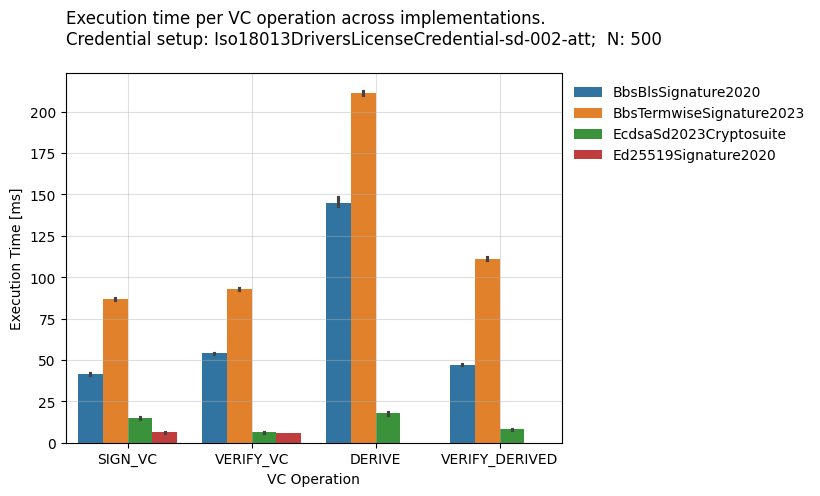

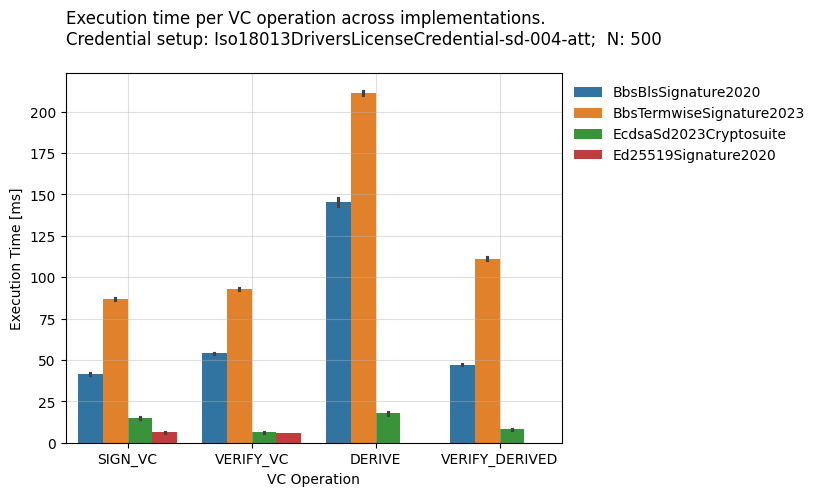

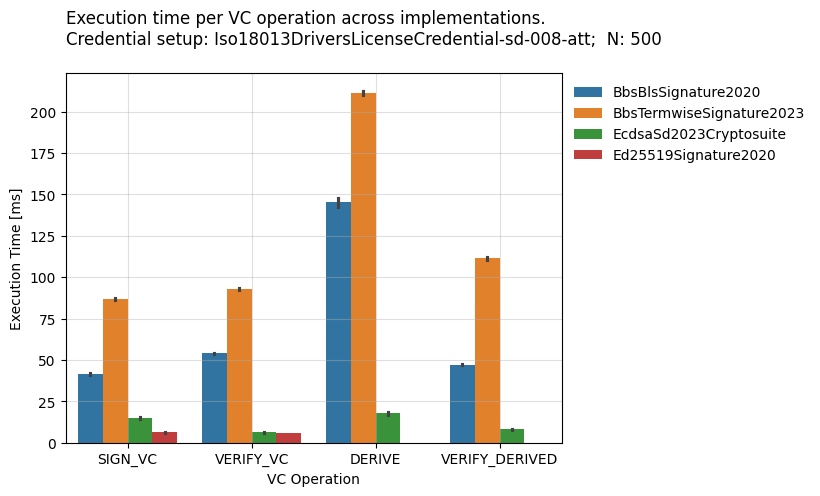

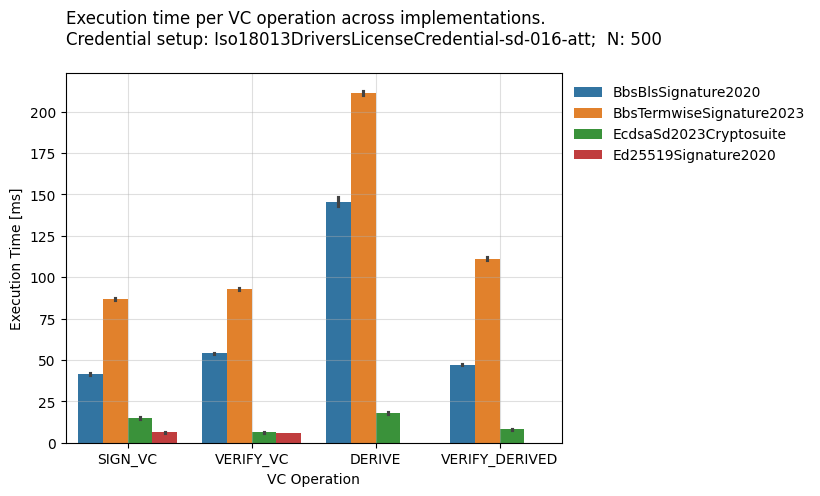

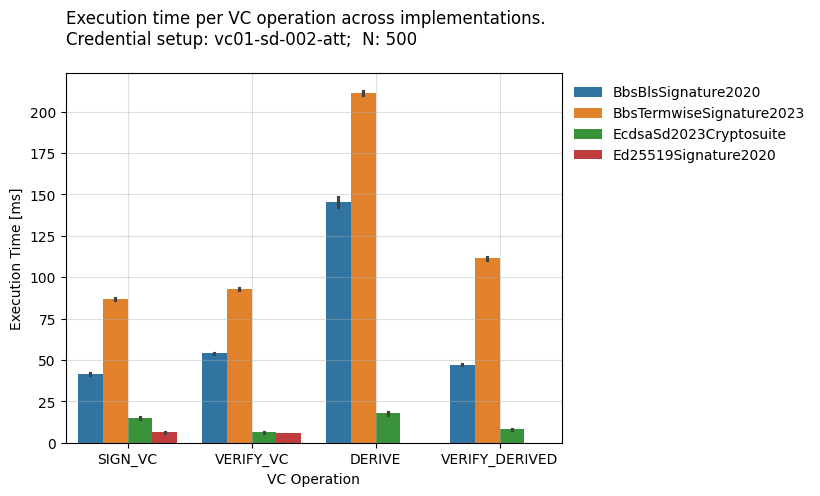

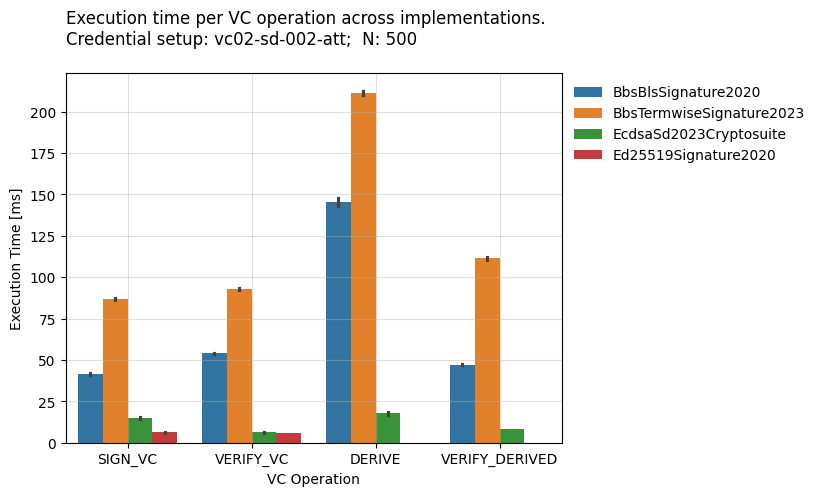

In [25]:
for csk in csk_vc.index:
    N = dfsb.iteration.max() + 1
    
    ax = sns.barplot(
        data = dfsb,
        x = 'step',
        y = 'delta',
        hue = 'implementation',
        order=step_order,
        hue_order=implementation_order
    )
    
    ax.legend(frameon=False, bbox_to_anchor=(1,1))
    ax.set_title(f'''Execution time per VC operation across implementations.\nCredential setup: {csk};  N: {N}
    ''',loc='left')
    ax.set_xlabel('VC Operation')
    ax.set_ylabel('Execution Time [ms]')
    ax.grid(alpha=.4)
    plt.show()

#### Focussing on each VC operation separately

Let's focus on each VC operation (denoted by the column `step`) separately.

In [26]:
STEPS = ['SIGN_VC', 'VERIFY_VC','DERIVE', 'VERIFY_DERIVED']

Let's iterate over each step (`step_i`), and plot execution times for that step across crypto suite implementations (`implementation`) and credential setups (`credentialSetupKey`).

/var/folders/tf/j9ycytm53pzbs56ftdt8rp_w0000gn/T/ipykernel_2948/4144021870.py:15: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


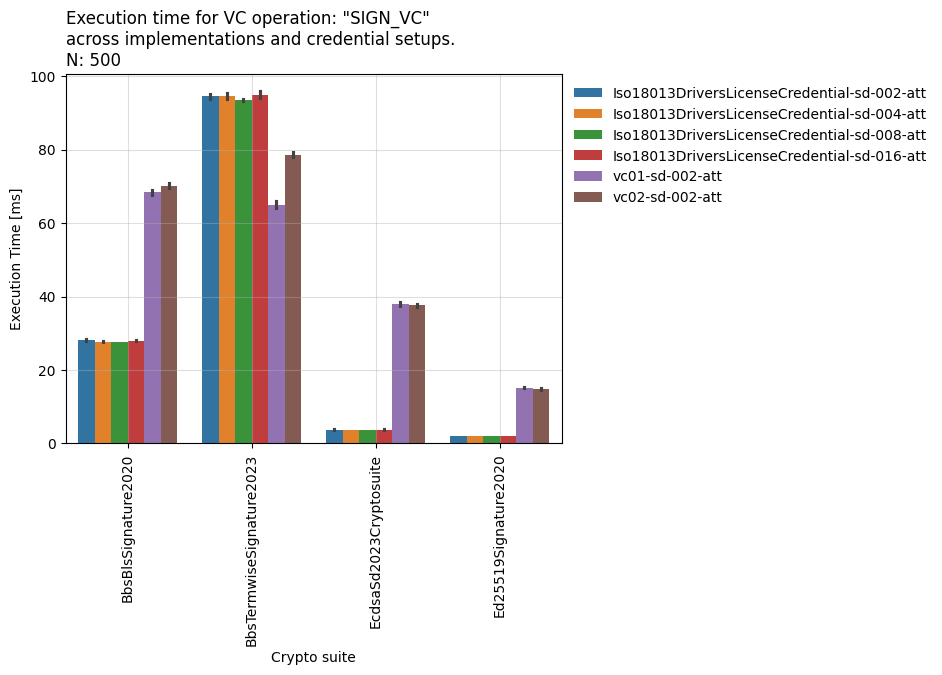

/var/folders/tf/j9ycytm53pzbs56ftdt8rp_w0000gn/T/ipykernel_2948/4144021870.py:15: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


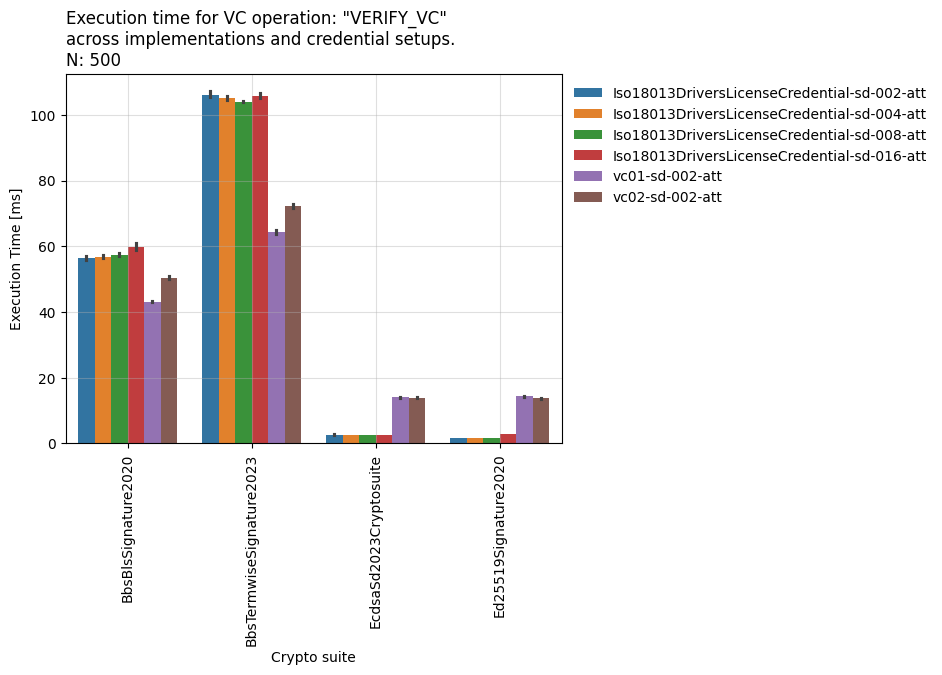

/var/folders/tf/j9ycytm53pzbs56ftdt8rp_w0000gn/T/ipykernel_2948/4144021870.py:15: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


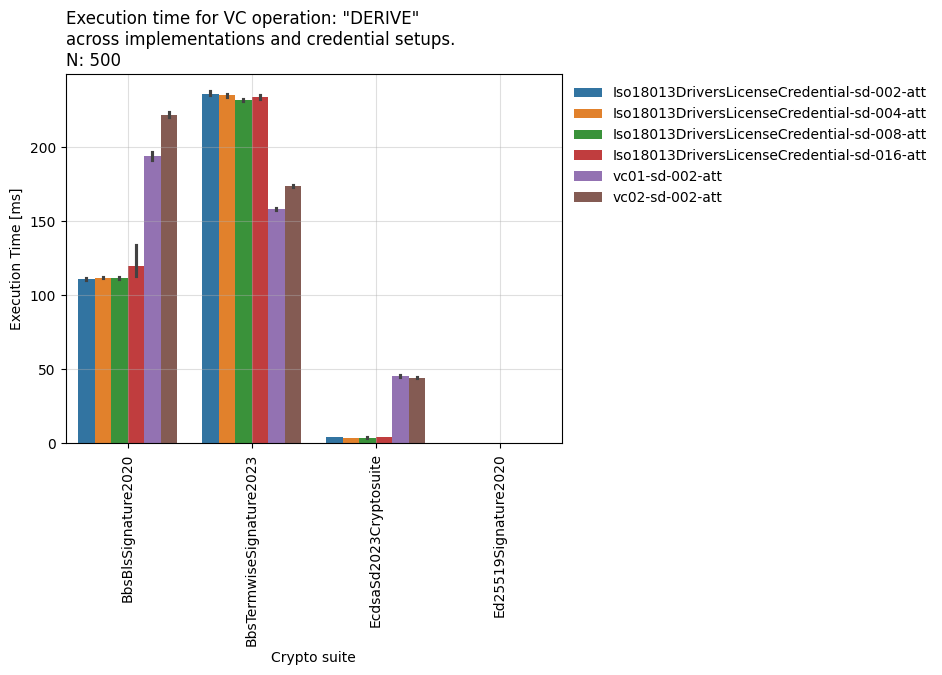

/var/folders/tf/j9ycytm53pzbs56ftdt8rp_w0000gn/T/ipykernel_2948/4144021870.py:15: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


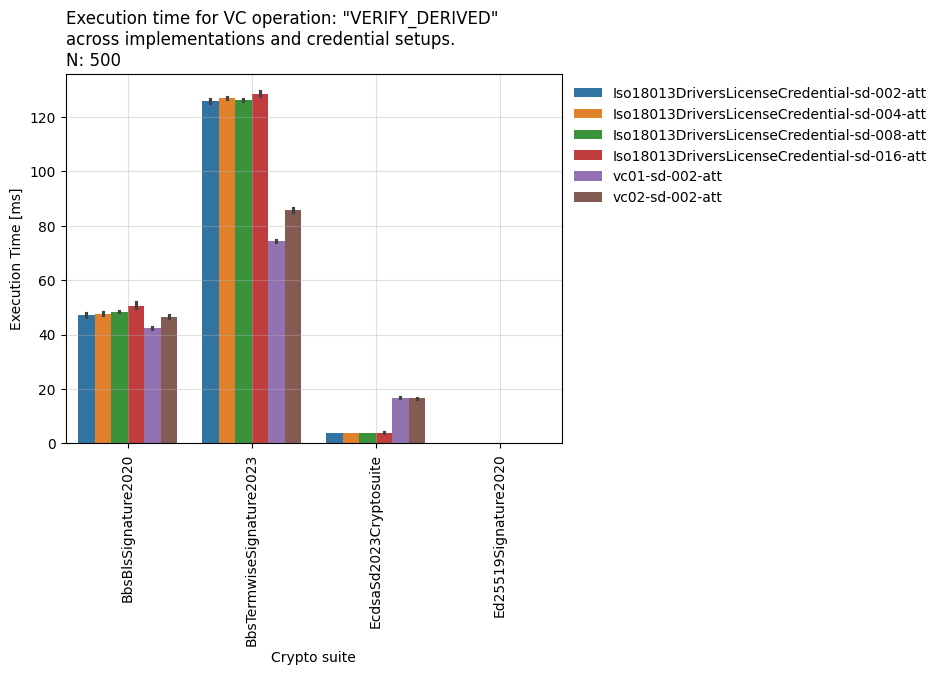

In [27]:
for step_i in STEPS:
    dfsb_step_i = dfsb[dfsb.step == step_i]
    ax = sns.barplot(
            data = dfsb_step_i,
            x = 'implementation',
            y = 'delta',
            hue = 'credentialSetupKey',
            order=implementation_order
        )
    ax.legend(frameon=False, bbox_to_anchor=(1,1))
    ax.set_title(f'''Execution time for VC operation: "{step_i}" \nacross implementations and credential setups.\nN: {N}''',loc='left')
    ax.set_xlabel('Crypto suite')
    ax.set_ylabel('Execution Time [ms]')
    ax.grid(alpha=.4)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
    plt.show()

---

### Considering every credential separately

In [28]:
cred = 'Iso18013DriversLicenseCredential'
assert cred in evaluated_credentials
print(f'Credential: {cred}')

Credential: Iso18013DriversLicenseCredential


In [29]:
dfsb_cred = dfsb[dfsb.credential == cred]
# Make sure we're dealing with exactly one credential
assert dfsb_cred.credential.unique().__len__() == 1

# Make sure that every implementation/credentialSetupKey/step has the same nr of records/measurements/values
assert dfsb_cred.groupby(['implementation', 'credentialSetupKey','step']).size().unique().__len__() == 1
n_iterations = dfsb_cred.groupby(['implementation', 'credentialSetupKey','step']).size().unique()[0]

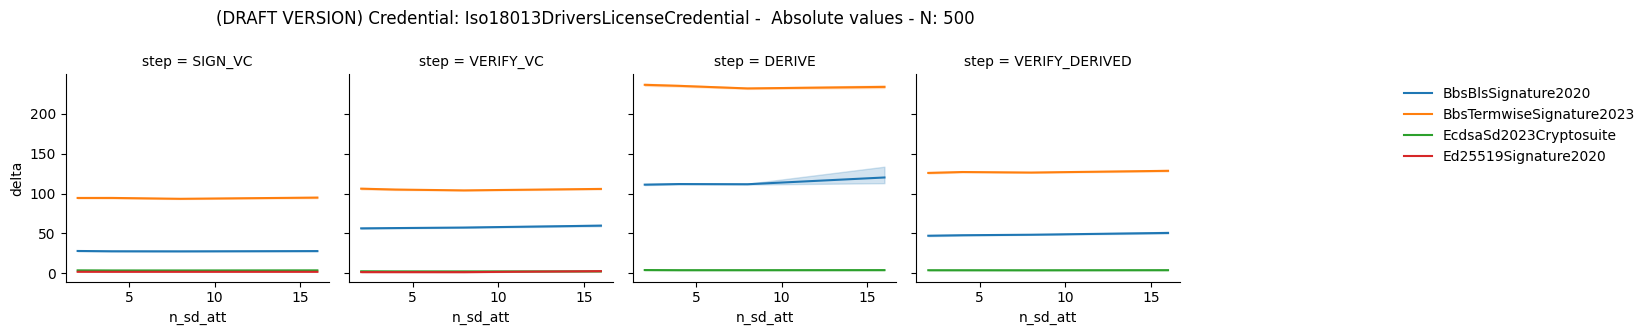

In [30]:
# This plot considers a range of values for n_sd_att
if dfsb_cred.n_sd_att.unique().__len__() > 1:
    g = sns.FacetGrid(dfsb_cred, col='step', col_order=STEPS, sharey=True)
    g.map_dataframe(sns.lineplot,
        x = 'n_sd_att',
        y = 'delta',
        hue = 'implementation',)
    
    g.axes.ravel()[0].legend(frameon=False, bbox_to_anchor=(6,1))
    #for ax in g.axes.ravel():
    #    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
    
    #ax.legend(frameon=False, bbox_to_anchor=(2,1))
    plt.suptitle(f'(DRAFT VERSION) Credential: {cred} -  Absolute values - N: {n_iterations}',y=1.1)
else:
    raise Warning(f'This plot considers a range of values for n_sd_att, which is not the case for credential: {cred}')

/var/folders/tf/j9ycytm53pzbs56ftdt8rp_w0000gn/T/ipykernel_2948/1559379516.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  dfsb_step_i = dfsb_cred[dfsb.step == step_i]


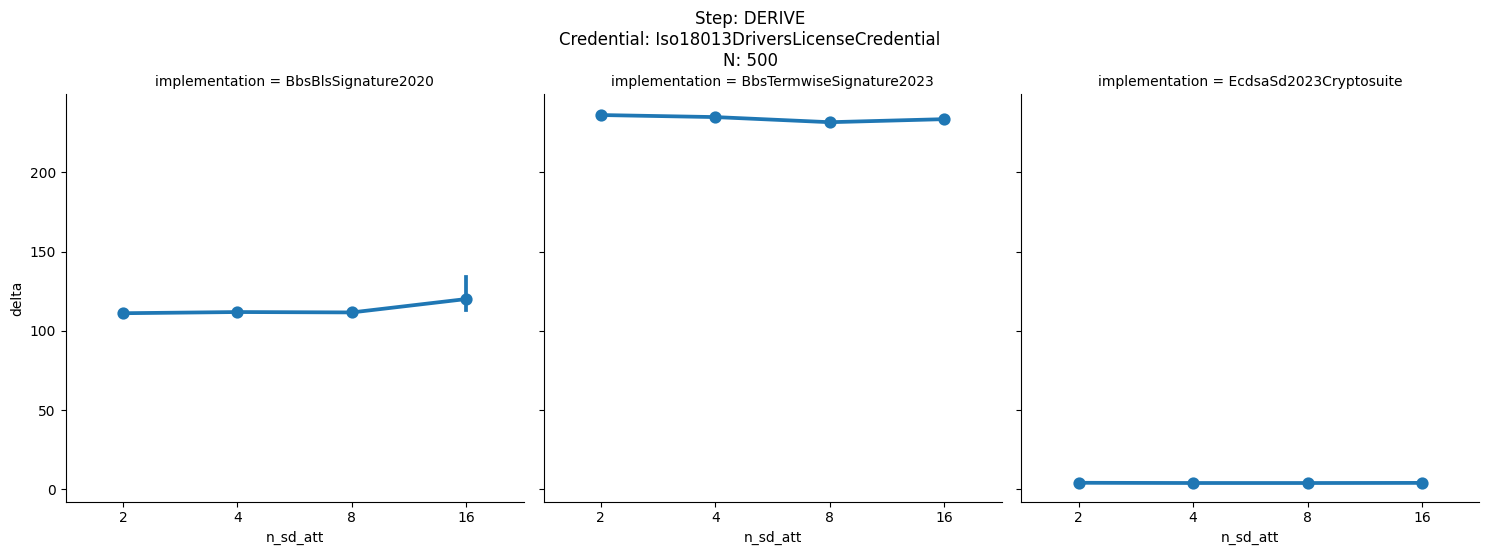

In [31]:
step_i = 'DERIVE'
# This plot considers a range of values for n_sd_att
if dfsb_cred.n_sd_att.unique().__len__() > 1:
    dfsb_step_i = dfsb_cred[dfsb.step == step_i]
    g = sns.catplot(
        data = dfsb_step_i,
        x = 'n_sd_att',
        y = 'delta',
        col = 'implementation',
        kind = 'point',
        aspect=1,
        sharey=True
    )
    plt.suptitle(f'Step: {step_i}\nCredential: {cred}\nN: {n_iterations}',y=1.1)
else:
    raise Warning(f'This plot considers a range of values for n_sd_att, which is not the case for credential: {cred}')

/var/folders/tf/j9ycytm53pzbs56ftdt8rp_w0000gn/T/ipykernel_2948/2762483159.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  dfsb_step_i = dfsb_cred[dfsb.step == step_i]


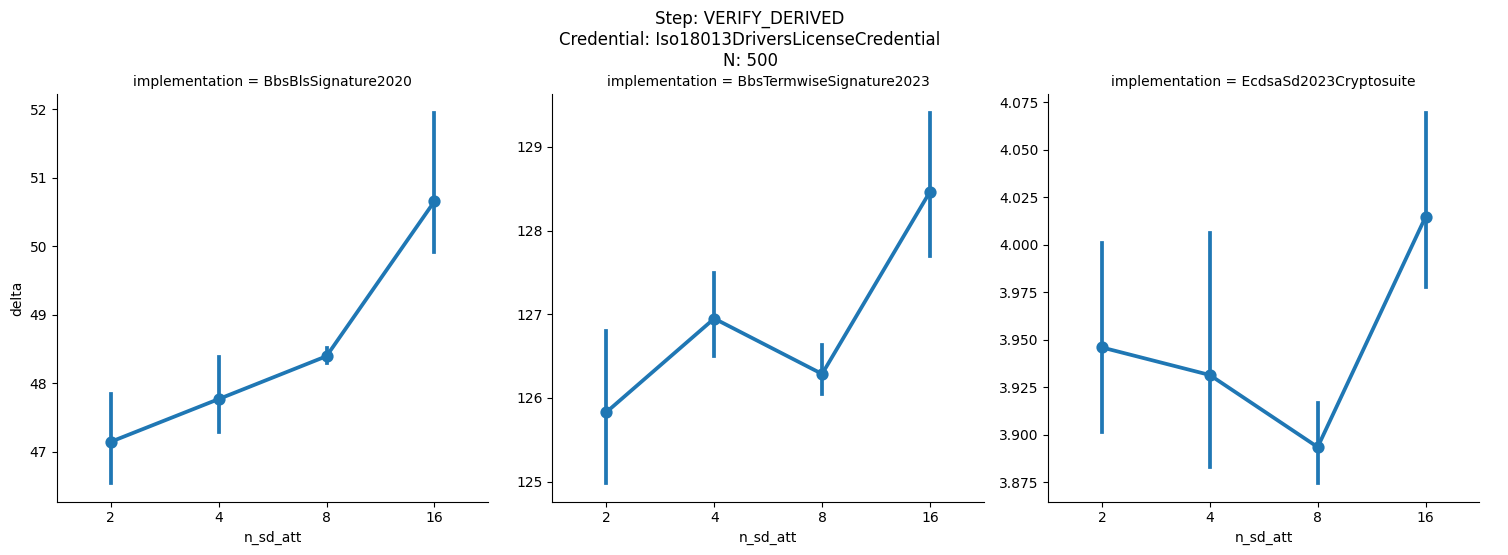

In [32]:
step_i = 'VERIFY_DERIVED'
# This plot considers a range of values for n_sd_att
if dfsb_cred.n_sd_att.unique().__len__() > 1:
    dfsb_step_i = dfsb_cred[dfsb.step == step_i]
    g = sns.catplot(
        data = dfsb_step_i,
        x = 'n_sd_att',
        y = 'delta',
        col = 'implementation',
        kind = 'point',
        aspect=1,
        sharey=False
    )
    plt.suptitle(f'Step: {step_i}\nCredential: {cred}\nN: {n_iterations}',y=1.1)
else:
    raise Warning(f'This plot considers a range of values for n_sd_att, which is not the case for credential: {cred}')

In [33]:
fpath_records

'./data/records-202502070205.json'

---

In [34]:
# The mean execution times for SIGN_VC & VERIFY_VC can be aggregated because the number of disclosed attributes does not influence their execution time
I = df_mean.stack().loc[['SIGN_VC','VERIFY_VC']]
#I.reset_index().credentialSetupKey.str.split('-sd-').apply(lambda x: x[0])
I['credentialSetupKey'] = pd.Series(I.index.get_level_values('credentialSetupKey')).str.split('-sd-').apply(lambda x: x[0]).values

In [35]:
# The mean execution times for SIGN_VC & VERIFY_VC can be aggregated because the number of disclosed attributes does not influence their execution time
I = df_mean.stack().loc[['SIGN_VC','VERIFY_VC']]
# To do this, we create the same credentialSetupKey for every -sd-\d{3} variant
new_credentialSetupKey_values = pd.Series(I.index.get_level_values('credentialSetupKey')).str.split('-sd-').apply(lambda x: x[0]).values
I.reset_index(inplace=True)
I['credentialSetupKey'] = new_credentialSetupKey_values
display(I)

# Let's aggregate
I_agg = I.reset_index().groupby(['step', 'credentialSetupKey']).mean().drop('index',axis=1)
print('I_agg')
display(I_agg)

# Execution times for DERIVE and VERIFY_DERIVED must be kept as-is (i.e., separated per nr of disclosed attributes)
J = df_mean.stack().loc[['DERIVE','VERIFY_DERIVED']]
print('J')
display(J)

implementation,step,credentialSetupKey,BbsBlsSignature2020,BbsTermwiseSignature2023,EcdsaSd2023Cryptosuite,Ed25519Signature2020
0,SIGN_VC,Iso18013DriversLicenseCredential,28.05,94.47,3.77,1.98
1,SIGN_VC,Iso18013DriversLicenseCredential,27.69,94.51,3.66,1.93
2,SIGN_VC,Iso18013DriversLicenseCredential,27.59,93.41,3.64,1.94
3,SIGN_VC,Iso18013DriversLicenseCredential,27.91,94.91,3.77,1.94
4,SIGN_VC,vc01,68.33,65.01,37.87,15.15
5,SIGN_VC,vc02,70.17,78.60,37.60,14.75
6,VERIFY_VC,Iso18013DriversLicenseCredential,56.38,106.10,2.62,1.59
7,VERIFY_VC,Iso18013DriversLicenseCredential,56.74,104.99,2.50,1.56
8,VERIFY_VC,Iso18013DriversLicenseCredential,57.39,103.94,2.47,1.53
9,VERIFY_VC,Iso18013DriversLicenseCredential,59.78,105.79,2.52,2.78


I_agg


implementation                              BbsBlsSignature2020  \
step      credentialSetupKey                                      
SIGN_VC   Iso18013DriversLicenseCredential              27.8100   
          vc01                                          68.3300   
          vc02                                          70.1700   
VERIFY_VC Iso18013DriversLicenseCredential              57.5725   
          vc01                                          43.1200   
          vc02                                          50.2900   

implementation                              BbsTermwiseSignature2023  \
step      credentialSetupKey                                           
SIGN_VC   Iso18013DriversLicenseCredential                    94.325   
          vc01                                                65.010   
          vc02                                                78.600   
VERIFY_VC Iso18013DriversLicenseCredential                   105.205   
          vc01                                                64.320   
          vc02                                                72.270   

implementation                              EcdsaSd2023Cryptosuite  \
step      credentialSetupKey                                         
SIGN_VC   Iso18013DriversLicenseCredential                  3.7100   
          vc01                                             37.8700   
          vc02                                             37.6000   
VERIFY_VC Iso18013DriversLicenseCredential                  2.5275   
          vc01                                             14.0500   
          vc02                                             13.9600   

implementation                              Ed25519Signature2020  
step      credentialSetupKey                                      
SIGN_VC   Iso18013DriversLicenseCredential                1.9475  
          vc01                                           15.1500  
          vc02                                           14.7500  
VERIFY_VC Iso18013DriversLicenseCredential                1.8650  
          vc01                                           14.3000  
          vc02                                           13.7500

J


implementation                                              BbsBlsSignature2020  \
step           credentialSetupKey                                                 
DERIVE         Iso18013DriversLicenseCredential-sd-002-att               111.14   
               Iso18013DriversLicenseCredential-sd-004-att               111.89   
               Iso18013DriversLicenseCredential-sd-008-att               111.65   
               Iso18013DriversLicenseCredential-sd-016-att               120.11   
               vc01-sd-002-att                                           194.01   
               vc02-sd-002-att                                           221.96   
VERIFY_DERIVED Iso18013DriversLicenseCredential-sd-002-att                47.14   
               Iso18013DriversLicenseCredential-sd-004-att                47.77   
               Iso18013DriversLicenseCredential-sd-008-att                48.39   
               Iso18013DriversLicenseCredential-sd-016-att                50.65   
               vc01-sd-002-att                                            42.50   
               vc02-sd-002-att                                            46.56   

implementation                                              BbsTermwiseSignature2023  \
step           credentialSetupKey                                                      
DERIVE         Iso18013DriversLicenseCredential-sd-002-att                    236.20   
               Iso18013DriversLicenseCredential-sd-004-att                    234.91   
               Iso18013DriversLicenseCredential-sd-008-att                    231.68   
               Iso18013DriversLicenseCredential-sd-016-att                    233.60   
               vc01-sd-002-att                                                158.13   
               vc02-sd-002-att                                                173.67   
VERIFY_DERIVED Iso18013DriversLicenseCredential-sd-002-att                    125.83   
               Iso18013DriversLicenseCredential-sd-004-att                    126.95   
               Iso18013DriversLicenseCredential-sd-008-att                    126.29   
               Iso18013DriversLicenseCredential-sd-016-att                    128.46   
               vc01-sd-002-att                                                 74.44   
               vc02-sd-002-att                                                 85.64   

implementation                                              EcdsaSd2023Cryptosuite  \
step           credentialSetupKey                                                    
DERIVE         Iso18013DriversLicenseCredential-sd-002-att                    4.15   
               Iso18013DriversLicenseCredential-sd-004-att                    4.01   
               Iso18013DriversLicenseCredential-sd-008-att                    4.00   
               Iso18013DriversLicenseCredential-sd-016-att                    4.08   
               vc01-sd-002-att                                               45.58   
               vc02-sd-002-att                                               44.49   
VERIFY_DERIVED Iso18013DriversLicenseCredential-sd-002-att                    3.95   
               Iso18013DriversLicenseCredential-sd-004-att                    3.93   
               Iso18013DriversLicenseCredential-sd-008-att                    3.89   
               Iso18013DriversLicenseCredential-sd-016-att                    4.01   
               vc01-sd-002-att                                               16.80   
               vc02-sd-002-att                                               16.58   

implementation                                              Ed25519Signature2020  
step           credentialSetupKey                                                 
DERIVE         Iso18013DriversLicenseCredential-sd-002-att                   NaN  
               Iso18013DriversLicenseCredential-sd-004-att                   NaN  
               Iso18013DriversLicenseCredential-sd-008-att         

In [36]:
I_agg

implementation                              BbsBlsSignature2020  \
step      credentialSetupKey                                      
SIGN_VC   Iso18013DriversLicenseCredential              27.8100   
          vc01                                          68.3300   
          vc02                                          70.1700   
VERIFY_VC Iso18013DriversLicenseCredential              57.5725   
          vc01                                          43.1200   
          vc02                                          50.2900   

implementation                              BbsTermwiseSignature2023  \
step      credentialSetupKey                                           
SIGN_VC   Iso18013DriversLicenseCredential                    94.325   
          vc01                                                65.010   
          vc02                                                78.600   
VERIFY_VC Iso18013DriversLicenseCredential                   105.205   
          vc01                                                64.320   
          vc02                                                72.270   

implementation                              EcdsaSd2023Cryptosuite  \
step      credentialSetupKey                                         
SIGN_VC   Iso18013DriversLicenseCredential                  3.7100   
          vc01                                             37.8700   
          vc02                                             37.6000   
VERIFY_VC Iso18013DriversLicenseCredential                  2.5275   
          vc01                                             14.0500   
          vc02                                             13.9600   

implementation                              Ed25519Signature2020  
step      credentialSetupKey                                      
SIGN_VC   Iso18013DriversLicenseCredential                1.9475  
          vc01                                           15.1500  
          vc02                                           14.7500  
VERIFY_VC Iso18013DriversLicenseCredential                1.8650  
          vc01                                           14.3000  
          vc02                                           13.7500

In [37]:
# The concatenated result: K = I_agg & J
K = pd.concat([I_agg, J], axis=0)
K

implementation                                              BbsBlsSignature2020  \
step           credentialSetupKey                                                 
SIGN_VC        Iso18013DriversLicenseCredential                         27.8100   
               vc01                                                     68.3300   
               vc02                                                     70.1700   
VERIFY_VC      Iso18013DriversLicenseCredential                         57.5725   
               vc01                                                     43.1200   
               vc02                                                     50.2900   
DERIVE         Iso18013DriversLicenseCredential-sd-002-att             111.1400   
               Iso18013DriversLicenseCredential-sd-004-att             111.8900   
               Iso18013DriversLicenseCredential-sd-008-att             111.6500   
               Iso18013DriversLicenseCredential-sd-016-att             120.1100   
               vc01-sd-002-att                                         194.0100   
               vc02-sd-002-att                                         221.9600   
VERIFY_DERIVED Iso18013DriversLicenseCredential-sd-002-att              47.1400   
               Iso18013DriversLicenseCredential-sd-004-att              47.7700   
               Iso18013DriversLicenseCredential-sd-008-att              48.3900   
               Iso18013DriversLicenseCredential-sd-016-att              50.6500   
               vc01-sd-002-att                                          42.5000   
               vc02-sd-002-att                                          46.5600   

implementation                                              BbsTermwiseSignature2023  \
step           credentialSetupKey                                                      
SIGN_VC        Iso18013DriversLicenseCredential                               94.325   
               vc01                                                           65.010   
               vc02                                                           78.600   
VERIFY_VC      Iso18013DriversLicenseCredential                              105.205   
               vc01                                                           64.320   
               vc02                                                           72.270   
DERIVE         Iso18013DriversLicenseCredential-sd-002-att                   236.200   
               Iso18013DriversLicenseCredential-sd-004-att                   234.910   
               Iso18013DriversLicenseCredential-sd-008-att                   231.680   
               Iso18013DriversLicenseCredential-sd-016-att                   233.600   
               vc01-sd-002-att                                               158.130   
               vc02-sd-002-att                                               173.670   
VERIFY_DERIVED Iso18013DriversLicenseCredential-sd-002-att                   125.830   
               Iso18013DriversLicenseCredential-sd-004-att                   126.950   
               Iso18013DriversLicenseCredential-sd-008-att                   126.290   
               Iso18013DriversLicenseCredential-sd-016-att                   128.460   
               vc01-sd-002-att                                                74.440   
               vc02-sd-002-att                                                85.640   

implementation                                              EcdsaSd2023Cryptosuite  \
step           credentialSetupKey                                                    
SIGN_VC        Iso18013DriversLicenseCredential                             3.7100   
               vc01                                                        37.8700   
               vc02                                                        37.6000   
VERIFY_VC      Iso18013DriversLicenseCredential                             2.5275   
               vc01                                           

---

In [38]:
df_mean_stacked = K.copy()
print('df_mean_stacked.shape: ', df_mean_stacked.shape)
display(df_mean_stacked)
df_mean_stacked.round(2).to_clipboard()
print('df_mean_stacked was copied to clipboard!')

df_mean_stacked.shape:  (18, 4)


implementation                                              BbsBlsSignature2020  \
step           credentialSetupKey                                                 
SIGN_VC        Iso18013DriversLicenseCredential                         27.8100   
               vc01                                                     68.3300   
               vc02                                                     70.1700   
VERIFY_VC      Iso18013DriversLicenseCredential                         57.5725   
               vc01                                                     43.1200   
               vc02                                                     50.2900   
DERIVE         Iso18013DriversLicenseCredential-sd-002-att             111.1400   
               Iso18013DriversLicenseCredential-sd-004-att             111.8900   
               Iso18013DriversLicenseCredential-sd-008-att             111.6500   
               Iso18013DriversLicenseCredential-sd-016-att             120.1100   
               vc01-sd-002-att                                         194.0100   
               vc02-sd-002-att                                         221.9600   
VERIFY_DERIVED Iso18013DriversLicenseCredential-sd-002-att              47.1400   
               Iso18013DriversLicenseCredential-sd-004-att              47.7700   
               Iso18013DriversLicenseCredential-sd-008-att              48.3900   
               Iso18013DriversLicenseCredential-sd-016-att              50.6500   
               vc01-sd-002-att                                          42.5000   
               vc02-sd-002-att                                          46.5600   

implementation                                              BbsTermwiseSignature2023  \
step           credentialSetupKey                                                      
SIGN_VC        Iso18013DriversLicenseCredential                               94.325   
               vc01                                                           65.010   
               vc02                                                           78.600   
VERIFY_VC      Iso18013DriversLicenseCredential                              105.205   
               vc01                                                           64.320   
               vc02                                                           72.270   
DERIVE         Iso18013DriversLicenseCredential-sd-002-att                   236.200   
               Iso18013DriversLicenseCredential-sd-004-att                   234.910   
               Iso18013DriversLicenseCredential-sd-008-att                   231.680   
               Iso18013DriversLicenseCredential-sd-016-att                   233.600   
               vc01-sd-002-att                                               158.130   
               vc02-sd-002-att                                               173.670   
VERIFY_DERIVED Iso18013DriversLicenseCredential-sd-002-att                   125.830   
               Iso18013DriversLicenseCredential-sd-004-att                   126.950   
               Iso18013DriversLicenseCredential-sd-008-att                   126.290   
               Iso18013DriversLicenseCredential-sd-016-att                   128.460   
               vc01-sd-002-att                                                74.440   
               vc02-sd-002-att                                                85.640   

implementation                                              EcdsaSd2023Cryptosuite  \
step           credentialSetupKey                                                    
SIGN_VC        Iso18013DriversLicenseCredential                             3.7100   
               vc01                                                        37.8700   
               vc02                                                        37.6000   
VERIFY_VC      Iso18013DriversLicenseCredential                             2.5275   
               vc01                                           

df_mean_stacked was copied to clipboard!


Relative performance results.

In [39]:
# relative to col
rel2c = 'EcdsaSd2023Cryptosuite'

In [40]:
# Compute relative performance
A = df_mean_stacked.values
B = df_mean_stacked[rel2c].values
C = (A.T / B).T
# df_C contains the performance values
df_C = pd.DataFrame(
    data=C,
    index=df_mean_stacked.index,
    columns=df_mean_stacked.columns
)
display(df_C.round(2))
df_C.round(2).to_clipboard()

implementation                                              BbsBlsSignature2020  \
step           credentialSetupKey                                                 
SIGN_VC        Iso18013DriversLicenseCredential                            7.50   
               vc01                                                        1.80   
               vc02                                                        1.87   
VERIFY_VC      Iso18013DriversLicenseCredential                           22.78   
               vc01                                                        3.07   
               vc02                                                        3.60   
DERIVE         Iso18013DriversLicenseCredential-sd-002-att                26.78   
               Iso18013DriversLicenseCredential-sd-004-att                27.90   
               Iso18013DriversLicenseCredential-sd-008-att                27.91   
               Iso18013DriversLicenseCredential-sd-016-att                29.44   
               vc01-sd-002-att                                             4.26   
               vc02-sd-002-att                                             4.99   
VERIFY_DERIVED Iso18013DriversLicenseCredential-sd-002-att                11.93   
               Iso18013DriversLicenseCredential-sd-004-att                12.16   
               Iso18013DriversLicenseCredential-sd-008-att                12.44   
               Iso18013DriversLicenseCredential-sd-016-att                12.63   
               vc01-sd-002-att                                             2.53   
               vc02-sd-002-att                                             2.81   

implementation                                              BbsTermwiseSignature2023  \
step           credentialSetupKey                                                      
SIGN_VC        Iso18013DriversLicenseCredential                                25.42   
               vc01                                                             1.72   
               vc02                                                             2.09   
VERIFY_VC      Iso18013DriversLicenseCredential                                41.62   
               vc01                                                             4.58   
               vc02                                                             5.18   
DERIVE         Iso18013DriversLicenseCredential-sd-002-att                     56.92   
               Iso18013DriversLicenseCredential-sd-004-att                     58.58   
               Iso18013DriversLicenseCredential-sd-008-att                     57.92   
               Iso18013DriversLicenseCredential-sd-016-att                     57.25   
               vc01-sd-002-att                                                  3.47   
               vc02-sd-002-att                                                  3.90   
VERIFY_DERIVED Iso18013DriversLicenseCredential-sd-002-att                     31.86   
               Iso18013DriversLicenseCredential-sd-004-att                     32.30   
               Iso18013DriversLicenseCredential-sd-008-att                     32.47   
               Iso18013DriversLicenseCredential-sd-016-att                     32.03   
               vc01-sd-002-att                                                  4.43   
               vc02-sd-002-att                                                  5.17   

implementation                                              EcdsaSd2023Cryptosuite  \
step           credentialSetupKey                                                    
SIGN_VC        Iso18013DriversLicenseCredential                                1.0   
               vc01                                                            1.0   
               vc02                                                            1.0   
VERIFY_VC      Iso18013DriversLicenseCredential                                1.0   
               vc01                                           

In [41]:
df_C.to_clipboard()

---

/var/folders/tf/j9ycytm53pzbs56ftdt8rp_w0000gn/T/ipykernel_2948/2095533028.py:1: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  dfsb_rel = df_C.drop(['SIGN_VC','VERIFY_VC'],axis=0).stack().rename('rel-delta').reset_index()
/var/folders/tf/j9ycytm53pzbs56ftdt8rp_w0000gn/T/ipykernel_2948/2095533028.py:10: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


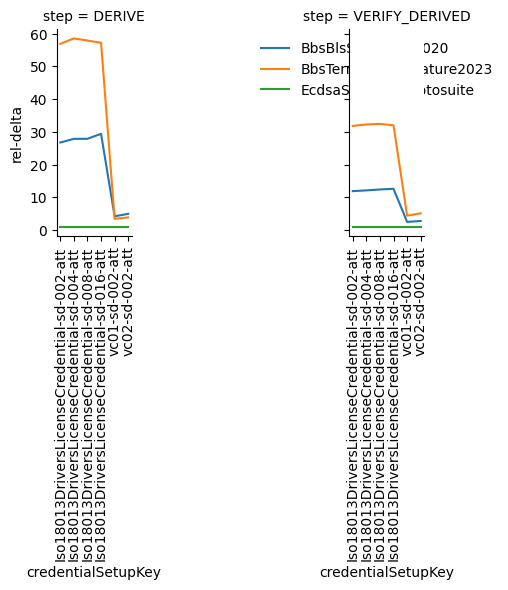

In [42]:
dfsb_rel = df_C.drop(['SIGN_VC','VERIFY_VC'],axis=0).stack().rename('rel-delta').reset_index()
g = sns.FacetGrid(dfsb_rel, col='step', row_order=STEPS, sharey=True, )
g.map_dataframe(sns.lineplot,
    x = 'credentialSetupKey',
    y = 'rel-delta',
    hue = 'implementation')

g.axes.ravel()[0].legend(frameon=False, bbox_to_anchor=(6,1))
for ax in g.axes.ravel():
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)

### Export to Excel

In [38]:
xlw = pd.ExcelWriter(fpath_xl_output)
df_stat.to_excel(xlw, sheet_name='df_stat')
df_mean.to_excel(xlw, sheet_name='df_mean')
xlw.close()

---
---
---

WIP: apply scaling

In [147]:
dfa.reset_index().credentialSetupKey.value_counts(dropna=False)

vc01-sd-002-att                                14000
vc02-sd-002-att                                14000
Iso18013DriversLicenseCredential-sd-002-att    14000
Iso18013DriversLicenseCredential-sd-004-att    14000
Iso18013DriversLicenseCredential-sd-008-att    14000
Iso18013DriversLicenseCredential-sd-016-att    14000
Name: credentialSetupKey, dtype: int64

In [149]:
dfa_w = dfa.unstack(['implementation', 'credentialSetupKey', 'stepType'])
display(dfa_w.head(3))
dfa_w.shape

startTime               \
implementation           BbsBlsSignature2020                
credentialSetupKey           vc01-sd-002-att                
stepType                               START          END   
iteration step                                              
0         DERIVE                  872.746459  1046.204000   
          SIGN_VC                 688.945167   821.288959   
          VERIFY_DERIVED         1046.618875  1089.451542   

                                                                \
implementation           BbsTermwiseSignature2023                
credentialSetupKey                vc01-sd-002-att                
stepType                                    START          END   
iteration step                                                   
0         DERIVE                      1401.327709  1575.729667   
          SIGN_VC                     1090.840250  1269.457792   
          VERIFY_DERIVED              1576.128125  1658.080667   

                                                            \
implementation           Ed25519Signature2020                
credentialSetupKey            vc01-sd-002-att                
stepType                                START          END   
iteration step                                               
0         DERIVE                          NaN          NaN   
          SIGN_VC                 1659.646584  1683.015667   
          VERIFY_DERIVED                  NaN          NaN   

                                                              \
implementation           EcdsaSd2023Cryptosuite                
credentialSetupKey              vc01-sd-002-att                
stepType                                  START          END   
iteration step                                                 
0         DERIVE                    1771.860667  1825.831250   
          SIGN_VC                   1701.895042  1755.084834   
          VERIFY_DERIVED            1826.237209  1851.709709   

                                                             ...  \
implementation           BbsBlsSignature2020                 ...   
credentialSetupKey           vc02-sd-002-att                 ...   
stepType                               START            END  ...   
iteration step                                               ...   
0         DERIVE               455813.723750  456034.884167  ...   
          SIGN_VC              455695.930250  455765.054959  ...   
          VERIFY_DERIVED       456035.269667  456081.225125  ...   

                                                                      \
implementation                                EcdsaSd2023Cryptosuite   
credentialSetupKey       Iso18013DriversLicenseCredential-sd-008-att   
stepType                                                       START   
iteration step                                                         
0         DERIVE                                        1.790174e+06   
          SIGN_VC                                       1.790167e+06   
          VERIFY_DERIVED                                1.790179e+06   

                                        \
implementation                           
credentialSetupKey                       
stepType                           END   
iteration step                           
0         DERIVE          1.790179e+06   
          SIGN_VC         1.790171e+06   
          VERIFY_DERIVED  1.790183e+06   

                                                                      \
implementation                                   BbsBlsSignature2020   
credentialSetupKey       Iso18013DriversLicenseCredential-sd-016-att   
stepType                                                       START   
iteration step                                                         
0         DERIVE                                        2.204996e+06   
          SIGN_VC                                       2.204911e+06   
          VERIFY_DERIVED                    

(2000, 48)

In [152]:
# dfa_w01: Only SIGN and VERIFY steps
dfa_w01 = dfa_w.drop(['DERIVE', 'VERIFY_DERIVED'], level=1)
# dfa_w02: Only DERIVE and VERIFY_DERIVED steps
dfa_w02 = dfa_w.drop(['SIGN_VC', 'VERIFY_VC'], level=1)

In [171]:
dfa_w01

startTime                 \
implementation      BbsBlsSignature2020                  
credentialSetupKey      vc01-sd-002-att                  
stepType                          START            END   
iteration step                                           
0         SIGN_VC            688.945167     821.288959   
          VERIFY_VC          821.726584     872.036792   
1         SIGN_VC           1855.146209    1931.344250   
          VERIFY_VC         1931.670875    1972.891167   
2         SIGN_VC           2705.957042    2773.960000   
...                                 ...            ...   
497       VERIFY_VC       453015.556959  453058.296000   
498       SIGN_VC         453862.501750  453927.308125   
          VERIFY_VC       453927.665584  453970.389375   
499       SIGN_VC         454775.744417  454842.289167   
          VERIFY_VC       454842.555125  454888.499875   

                                                             \
implementation      BbsTermwiseSignature2023                  
credentialSetupKey           vc01-sd-002-att                  
stepType                               START            END   
iteration step                                                
0         SIGN_VC                1090.840250    1269.457792   
          VERIFY_VC              1269.866084    1336.355792   
1         SIGN_VC                2162.433125    2216.719250   
          VERIFY_VC              2217.086292    2281.832250   
2         SIGN_VC                3004.367000    3058.783209   
...                                      ...            ...   
497       VERIFY_VC            453379.816292  453443.098417   
498       SIGN_VC              454222.738584  454293.518292   
          VERIFY_VC            454293.877584  454357.093292   
499       SIGN_VC              455144.846667  455213.563250   
          VERIFY_VC            455213.904625  455277.233084   

                                                         \
implementation      Ed25519Signature2020                  
credentialSetupKey       vc01-sd-002-att                  
stepType                           START            END   
iteration step                                            
0         SIGN_VC            1659.646584    1683.015667   
          VERIFY_VC          1683.364584    1699.640125   
1         SIGN_VC            2557.634167    2571.638209   
          VERIFY_VC          2571.945709    2585.635167   
2         SIGN_VC            3400.423084    3414.251584   
...                                  ...            ...   
497       VERIFY_VC        453733.744209  453747.007250   
498       SIGN_VC          454630.817792  454646.177959   
          VERIFY_VC        454646.536084  454659.512209   
499       SIGN_VC          455554.513250  455567.811917   
          VERIFY_VC        455568.079959  455581.627917   

                                                                               \
implementation      EcdsaSd2023Cryptosuite                BbsBlsSignature2020   
credentialSetupKey         vc01-sd-002-att                    vc02-sd-002-att   
stepType                             START            END               START   
iteration step                                                                  
0         SIGN_VC              1701.895042    1755.084834       455695.930250   
          VERIFY_VC            1755.441917    1771.451750       455765.389084   
1         SIGN_VC              2588.774042    2626.906709       456674.459959   
          VERIFY_VC            2627.301042    2641.888375       456743.340917   
2         SIGN_VC              3432.073625    3470.333209       457660.559875   
...                                    ...            ...                 ...   
497       VERIFY_VC          453783.826959  453797.465709       950015.771792   
498       SIGN_VC            454660.201917  454698.565250       950933.389584   
          VERIFY_VC          454698.886459  454712.751917       951002.439917   
499       SIG

In [153]:
def scale(df: pd.DataFrame) -> pd.DataFrame:
    sclr = skp.StandardScaler()
    return pd.DataFrame(
        data = sclr.fit_transform(df),
        columns = df.columns,
        index = df.index
    )
def add_delta_col(df: pd.DataFrame) -> pd.DataFrame:
    tmp = df.stack([0,1,2])
    tmp = (tmp.END - tmp.START).droplevel(level=2).rename('delta')
    return tmp.reset_index()

def add_credential_col(df: pd.DataFrame) -> pd.DataFrame:
    df['credential'] = pd.Series(df.credentialSetupKey.str.split('-sd-').apply(lambda x: x[0]).values)
    return df

def add_n_sd_att_col(df: pd.DataFrame) -> pd.DataFrame:
    df['n_sd_att'] = df.credentialSetupKey.apply(extract_nr_of_sd_attributes)
    return df

def run_preprocessing_steps(df: pd.DataFrame) -> pd.DataFrame:
    df_scld = scale(df)
    df_scld = add_delta_col(df_scld)
    df_scld = add_credential_col(df_scld)
    df_scld = add_n_sd_att_col(df_scld)
    return df_scld

In [154]:
dfsb_dfa_w01 = run_preprocessing_steps(dfa_w01)
dfsb_dfa_w02 = run_preprocessing_steps(dfa_w02)

/Users/gertjandm/miniforge3/lib/python3.9/site-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/Users/gertjandm/miniforge3/lib/python3.9/site-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/Users/gertjandm/miniforge3/lib/python3.9/site-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


In [170]:
dfsb_dfa_w01[
    (dfsb_dfa_w01.implementation == 'BbsBlsSignature2020')&
    (dfsb_dfa_w01.step == 'SIGN_VC')&
    (dfsb_dfa_w01.credential == 'Iso18013DriversLicenseCredential')
].delta.describe()

count    2000.000000
mean       -0.000123
std         0.000019
min        -0.000142
25%        -0.000127
50%        -0.000124
75%        -0.000120
max         0.000415
Name: delta, dtype: float64

SIGN AND VERIFY

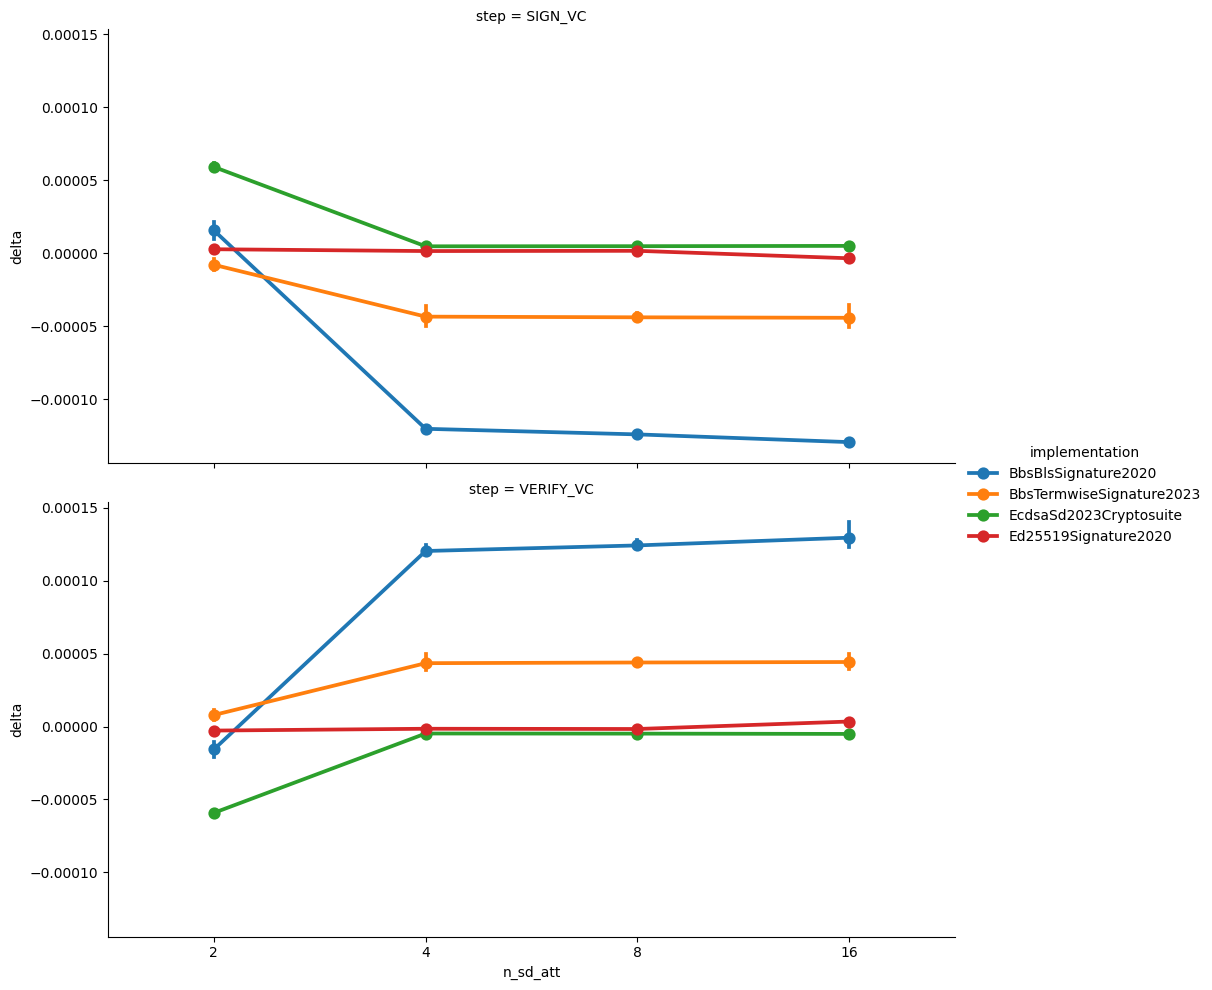

In [134]:
# SIGN AND VERIFY
snsdata = dfsb_dfa_w01.copy()
g = sns.catplot(
        data = snsdata,
        x = 'n_sd_att',
        y = 'delta',
        hue = 'implementation',
        row = 'step',
        row_order = ['SIGN_VC', 'VERIFY_VC'],
        kind = 'point',
        aspect=2,
        sharey=True
    )

DERIVE & VERIFY_DERIVED

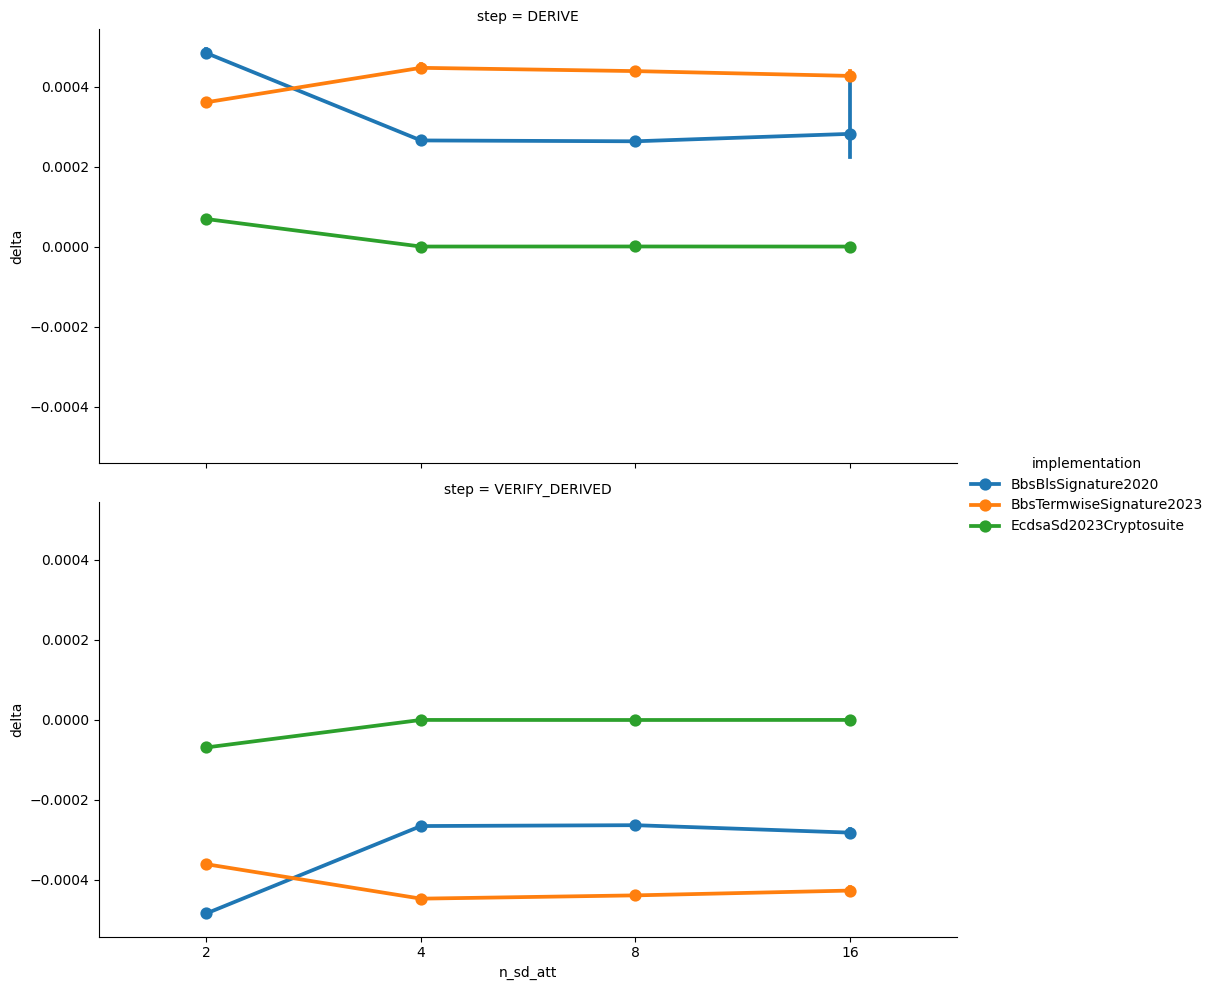

In [135]:
# DERIVE & VERIFY_DERIVED

snsdata = dfsb_dfa_w02.copy()

g = sns.catplot(
        data = snsdata,
        x = 'n_sd_att',
        y = 'delta',
        row = 'step',
        row_order = ['DERIVE', 'VERIFY_DERIVED'],
        hue = 'implementation',
        kind = 'point',
        aspect=2,
        sharey=True
    )

----